In [1]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support
)


In [2]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'Dut_hoan_toan_1_3_tren':1,
            'Dut_hoan_toan_1_3_duoi':2,
            'Dut_hoan_toan_1_3_giua':3,
            'Dut_ban_phan_1_3_tren':4,
            'Dut_ban_phan_1_3_duoi':5,
            'Dut_ban_phan_1_3_giua':6}

In [3]:
# seg,seg_header=nrrd.read(r"D:\personal_data\Duy Phan Ig\my_tool\Thanh dot 1\Le Van Chung_25938957\Segmentation.seg.nrrd")
# data_dict={k:v for k,v in seg_header.items() if k.startswith('Segment')}
# for i in range(len(data_dict)):
#     print(f"Key: {list(data_dict.keys())[i]}")
#     print(f"Value: {list(data_dict.values())[i]}")
#     print("=================================================")

In [4]:
pattern_name=re.compile(r"^Segment(\d+)_Name$")
pattern_tags=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
def get_tag_ACL(seg_header:Dict):
    seg_tags={k:v for k,v in seg_header.items() if ((m:=pattern_tags.match(k)) and (0<=int(m.group(1))<=5))}
    for i in range(len(seg_tags)):
        if list(seg_tags.values())[i].startswith(Segment_signal_string):
            return i 
def get_type_ACL(seg_header:Dict):
    tags=get_tag_ACL(seg_header)
    seg_names={k:v for k,v in seg_header.items() if ((m:=pattern_name.match(k)) and (0<=int(m.group(1))<=5))}
    name = seg_names[f"Segment{tags}_Name"]
    for i in range(len(label_type)):
        if name == list(label_type.keys())[i]:
            return list(label_type.values())[i]
    # for i in range(len(seg_names)):
    #     for j in range(len(label_type)):
    #         if (str(list(seg_names.values())[i])==str(list(label_type.keys())[j])):
    #             return list(label_type.values())[j]
def collect_data_and_seg(root_dir: str)->Dict:
    root_dir = Path(root_dir)
    result = {}
    for subfolder in root_dir.iterdir():
        if not subfolder.is_dir():
            continue
        # Find segmentation files
        seg_files = sorted(subfolder.glob("Segmentation*.seg.nrrd"))
        if not seg_files:
            continue
        # Find T2 files
        t2_files = sorted(
            p for p in subfolder.glob("*.nrrd")
            if "t2_tse_sag" in p.stem.lower()
        )
        if not t2_files:
            continue
        data,data_header=nrrd.read(t2_files[0])
        seg_data,seg_header=nrrd.read(seg_files[0])
        type_acl=get_type_ACL(seg_header)
        result[subfolder.name] = {
            "nrrd": data,
            "seg": seg_data,
            "type":type_acl
        }
    return result
root_dir=r"D:\personal_data\Duy Phan Ig\my_tool\Test_data_1"
data_dict=collect_data_and_seg(root_dir)
print(f"number of selected files: {len(data_dict)}")
for patient, data in data_dict.items():
    print(f"Patient {patient} with ACL type: {data['type']} ")

number of selected files: 39
Patient BUI NGUYEN BAO QUOC (18024987) with ACL type: 3 
Patient Cai Kim Loc_25210566 with ACL type: 6 
Patient DANG NGOC THO (19069990) with ACL type: 1 
Patient Ha Van Chau_20250507 with ACL type: 3 
Patient HUYNH PHUC THANH (25918976) with ACL type: 1 
Patient HUYNH THANH PHONG (25919398) with ACL type: 1 
Patient KHUAT THI THU HANG (22940170) with ACL type: 6 
Patient Le Thi Thuy_25193052 with ACL type: 5 
Patient Le Van Chung_25938957 with ACL type: 5 
Patient MAI THI BICH LOC (25073019) with ACL type: 6 
Patient NGO HONG PHAN (25158695) with ACL type: 1 
Patient Nguyen Hoang Gia Tuan_20250616 with ACL type: 3 
Patient Nguyen Huu Nghia_25246508 with ACL type: 3 
Patient NGUYEN KHANH THANH (25916940) with ACL type: 6 
Patient NGUYEN LE HOANG MINH (25918812) with ACL type: 6 
Patient Nguyen Minh Luan_24281378 with ACL type: 1 
Patient Nguyen Ngoc Dang Duong_20250529 (loi ve) with ACL type: 1 
Patient Nguyen Ngoc Long_20250911 with ACL type: 4 
Patient NG

In [5]:
class MRI_data(Dataset):
    def __init__(self,data_dict:Dict,img_trasform=None,label_transform=None,target_size=(320,320)):
        self.data_dict=data_dict
        self.img_transform=img_trasform
        self.label_transform=label_transform
        self.target_size=target_size
        self.samples=[]
        for patient, data in data_dict.items():
            nrrd_data=data['nrrd']
            seg_data=data['seg']
            type_acl=data['type']
            depth=nrrd_data.shape[2]
            for i in range(depth):
                img_slice=nrrd_data[:,:,i].astype(np.float32)
                seg_slice=seg_data[:,:,i]
                label = 0 if any(seg_slice.flatten())==False else type_acl
                self.samples.append((img_slice,label))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, index): 
        img,label=self.samples[index]
        img=img/np.max(img)                         # Normalize to [0,1]
        img=torch.tensor(img,dtype=torch.float32)   # Convert to tensor
        img=img.unsqueeze(0)                        # Add channel dimension

        label=torch.tensor(label,dtype=torch.long)  # Convert label to tensor
        if self.img_transform:
            img=self.img_transform(img)
        if self.label_transform:
            label=self.label_transform(label)
        return img,label 

In [6]:
img_transform=transforms.Compose([
    transforms.CenterCrop(320),
    transforms.RandomHorizontalFlip(0.2),
    transforms.RandomRotation(50),
    transforms.RandomAdjustSharpness(0,p=0.2)
])

In [7]:
dataset=MRI_data(data_dict=data_dict,img_trasform=img_transform)
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")

Dataset length: 970
Sample image shape: torch.Size([1, 320, 320]), Sample label: 6


In [9]:
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 679
Validation set size: 291


Overall Dataset Label Distribution:


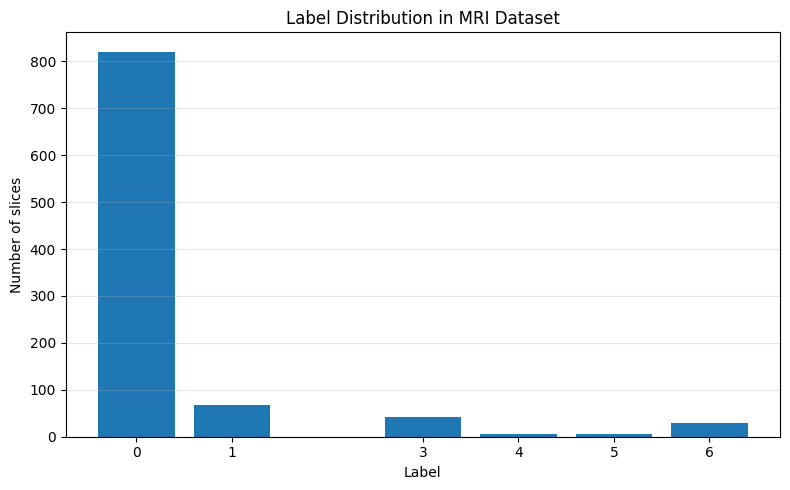

Label 0: 821 samples
Label 1: 68 samples
Label 3: 41 samples
Label 4: 6 samples
Label 5: 5 samples
Label 6: 29 samples
Training Set Label Distribution:


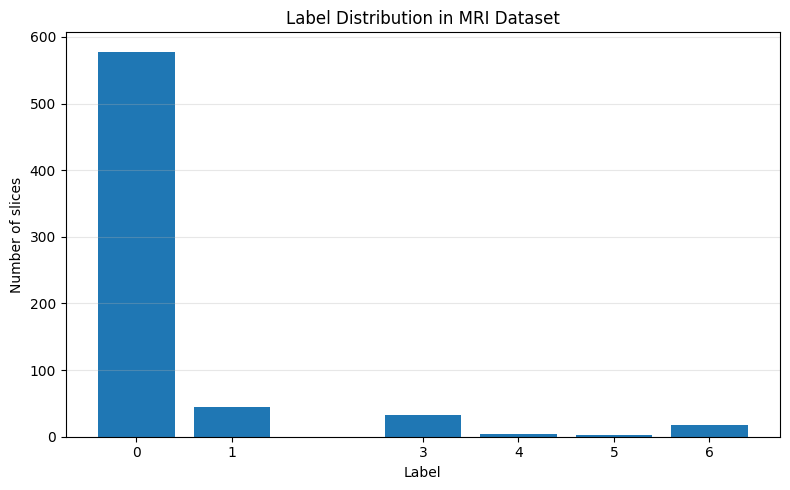

Label 0: 578 samples
Label 1: 44 samples
Label 3: 32 samples
Label 4: 4 samples
Label 5: 3 samples
Label 6: 18 samples
Validation Set Label Distribution:


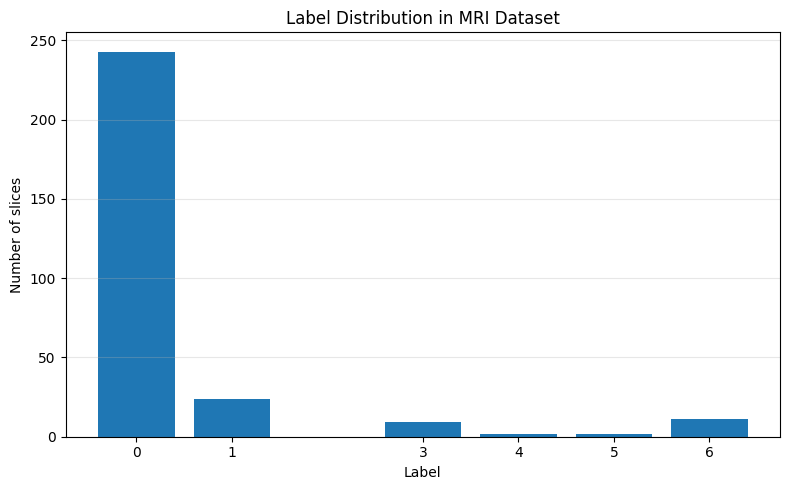

Label 0: 243 samples
Label 1: 24 samples
Label 3: 9 samples
Label 4: 2 samples
Label 5: 2 samples
Label 6: 11 samples


In [10]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of slices")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [11]:
target=[]
for _, label in train_dataset:
    if isinstance(label, torch.Tensor):
        label = label.item()
    target.append(label)
target=torch.tensor(target,dtype=torch.long)
# 1) unique classes
classes = torch.unique(target, sorted=True)
print(f"Unique classes in training set: {classes}")
# 2) mapping: label → index
class_to_index = {int(c): i for i, c in enumerate(classes)}
# 3) count samples per class
class_samples_count = torch.tensor([
    (target == c).sum() for c in classes
], dtype=torch.float)
# 4) class weights
weight = 1.0 / class_samples_count
# 5) sample weights (SAFE)
samples_weight = torch.tensor(
    [weight[class_to_index[int(t)]] for t in target],
    dtype=torch.float
)
# 6) sampler
sampler = torch.utils.data.WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)


Unique classes in training set: tensor([0, 1, 3, 4, 5, 6])


In [12]:
train_loader = DataLoader(train_dataset,batch_size=16,sampler=sampler,shuffle=False)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=True)

In [42]:

wandb.login(relogin=True)


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Admin\.netrc


True

In [13]:
ARCH={
    'cnn1':
    {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':3,
        'number_of_fc_layer':2,
        'num_classes':7,
        'conv_channels': [6, 16,24],
        'fc_feature':[104,7]
    },
    'cnn2':
    {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':4,
        'number_of_fc_layer':3,
        'num_classes':7,
        'conv_channels': [6, 16,24,32],
        'fc_feature':[104,64,7]
    }
}

In [ ]:
import copy
import torch

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode="min", restore_best_weights=True):
        """
        mode: "min" for val_loss, "max" for val_acc
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best_weights = restore_best_weights
    
        self.best_score = None
        self.best_state = None
        self.counter = 0
        self.should_stop = False

    def _is_improvement(self, score):
        if self.best_score is None:
            return True
        if self.mode == "min":
            return score < (self.best_score - self.min_delta)
        else:  # "max"
            return score > (self.best_score + self.min_delta)

    def step(self, score, model):
        """
        Call at end of each epoch with validation metric.
        Returns True if training should stop.
        """
        if self._is_improvement(score):
            self.best_score = score
            self.counter = 0
            if self.restore_best_weights:
                self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def restore(self, model):
        if self.restore_best_weights and self.best_state is not None:
            model.load_state_dict(self.best_state)

In [ ]:
class TrainerWB: 
    def __init__(self,config,train_dataset,val_dataset): 
        self.config=config
        self.device=torch.device('cuda' if torch.cuda.is_available() else'cpu')
        self.epochs=config.epoch
        self.learning_rate=config.lr
        self.batch_size=config.batch_size
    
        self.train_loader=DataLoader(train_dataset,batch_size=self.batch_size,sampler=sampler,shuffle=False)
        self.val_loader=DataLoader(val_dataset,batch_size=self.batch_size,shuffle=False)
 
        para=ARCH[config.architecture]
        self.model=LeNet(para).to(self.device)
    
        self.criterion=nn.CrossEntropyLoss()
        self.optimizer=self.optim_build()
        self.scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer,T_max=self.epochs)
        wandb.config.update({"model_para": para}, allow_val_change=True)

    def optim_build(self): 
        if self.config['optim']=='SGD': 
            return optim.SGD(self.model.parameters(), lr=self.learning_rate, momentum=0.9) 
        elif self.config['optim']=='Adam': 
            return optim.Adam(self.model.parameters(), lr=self.learning_rate) 
        else: 
            raise ValueError("Unsupported optimizer type") 
    def train(self): 
        self.model.train()
        running_loss=0.0 
        correct=0
        total=0 
        loop=tqdm(self.train_loader,desc='Tao dang training',leave=False) 
        for image, label in loop: 
            image,label= image.to(self.device), label.to(self.device) 
            #Forward propagation: 
            output=self.model(image) 
            loss=self.criterion(output,label) 
            #backward propagation 
            self.optimizer.zero_grad() 
            loss.backward() 
            self.optimizer.step() 
            #Metrics calculation 
            running_loss += loss.item() 
            preds=torch.argmax(output,dim=1) 
            correct += (preds==label).sum().item() 
            total += label.size(0)
             #Update progress bar 
            loop.set_postfix(loss=running_loss/ (total/self.batch_size), accuracy=100.* correct/ total) 
        avg_loss = running_loss / total 
        accuracy = correct / total 
        return avg_loss, accuracy 
    def validate(self):
        self.model.eval()
        running_loss = 0.0
        total = 0

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                total += labels.size(0)

                preds = torch.argmax(outputs, dim=1)

                # 🔹 store for metrics
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        avg_loss = running_loss / total

        # concatenate all batches
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()

        # accuracy
        accuracy = (all_preds == all_labels).mean()

        # precision, recall, f1 (macro)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average="macro",
            zero_division=0
        )

        # confusion matrix
        cm = confusion_matrix(all_labels, all_preds)

        return avg_loss, accuracy, precision, recall, f1, cm,all_labels,all_preds

    def fit(self): 
        for epoch in range(self.epochs): 
            train_loss, train_acc = self.train() 
            val_loss, val_acc, val_prec, val_rec, val_f1, cm, all_labels,all_preds = self.validate()
            if epoch%5==0:
                print(f"Epoch [{epoch+1}/{self.epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}") 
            wandb.log({
                "Validation Loss": val_loss,
                "Validation Accuracy": val_acc,
                "Validation Precision (macro)": val_prec,
                "Validation Recall (macro)": val_rec,
                "Validation F1 (macro)": val_f1,
                "Confusion Matrix": wandb.plot.confusion_matrix(
                        probs=None,
                        y_true=all_labels,
                        preds=all_preds,
                        class_names=[str(i) for i in range(cm.shape[0])]
                    )
            })
        print("Training complete.")

In [16]:
early_stopper=EarlyStopping(patience=10, min_delta=1e-5, mode="max")
def main():
    with wandb.init(project="ACL_Classification", reinit=True):
        trainer = TrainerWB(
            config=wandb.config,
            train_dataset=train_dataset,
            val_dataset=val_dataset
        )
        trainer.fit()

In [17]:
sweep_config={
    'method':'random',
    'metric':{
        'name':'Validation Accuracy',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[0.001,0.0001]
        },
        'epoch':{
            'values':[70,80,90]
        },
        'batch_size':{
            'values':[2,4,8,16]
        },
        'optim':{
            'values':['SGD']
        },
        'architecture':{
            'values':['cnn1','cnn2']
        }
    }
}

In [18]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification")
wandb.agent(sweep_id, function=main, count=10)

Create sweep with ID: 5g3vgovi
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification/sweeps/5g3vgovi


wandb: Agent Starting Run: 2zmurj6z with config:
wandb: 	architecture: cnn2
wandb: 	batch_size: 2
wandb: 	epoch: 80
wandb: 	lr: 0.0001
wandb: 	optim: SGD
wandb: Currently logged in as: baymaxnguyen306 (baymaxnguyen306-ho-chi-minh-city-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch [1/80], Train Loss: 2.0788, Train Acc: 0.0913, Val Loss: 4.1344, Val Acc: 0.1031


Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\1142143481.py", line 9, in main
    trainer.fit()
    ~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\3505329575.py", line 110, in fit
    "Confusion Matrix": wandb.plot.confusion_matrix(
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            probs=None,
            ^^^^^^^^^^^
    ...<2 lines>...
            class_names=[str(i) for i in range(cm.shape[0])]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        )
        ^
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\plot\confusion_matrix.py", line 164, in confusion_matrix
    counts[class_mapping[y_true[i]], class_mapping[preds[i]]] += 1
           ~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: np.int64(6)


...

Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\1142143481.py", line 9, in main
    trainer.fit()
    ~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\3505329575.py", line 110, in fit
    "Confusion Matrix": wandb.plot.confusion_matrix(
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            probs=None,
            ^^^^^^^^^^^
    ...<2 lines>...
            class_names=[str(i) for i in range(cm.shape[0])]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        )
        ^
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\plot\confusion_matrix.py", line 164, in confusion_matrix
    counts[class_mapping[y_true[i]], class_mapping[preds[i]]] += 1
           ~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: np.int64(6)


Traceback (most recent call last):
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\agents\pyagent.py", line 296, in _run_job
    self._function()
    ~~~~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\1142143481.py", line 9, in main
    trainer.fit()
    ~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\3505329575.py", line 110, in fit
    "Confusion Matrix": wandb.plot.confusion_matrix(
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            probs=None,
            ^^^^^^^^^^^
    ...<2 lines>...
            class_names=[str(i) for i in range(cm.shape[0])]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        )
        ^
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\plot\confusion_matrix.py", line 164, in confusion_matrix
    counts[class_mapping[y_true[i]], class_mapping[preds[i]]] += 1
           ~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: np.int64(6)

wandb: ERROR Run 

Epoch [1/90], Train Loss: 1.9961, Train Acc: 0.2268, Val Loss: 4.1032, Val Acc: 0.0825


Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\1142143481.py", line 9, in main
    trainer.fit()
    ~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\3505329575.py", line 110, in fit
    "Confusion Matrix": wandb.plot.confusion_matrix(
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            probs=None,
            ^^^^^^^^^^^
    ...<2 lines>...
            class_names=[str(i) for i in range(cm.shape[0])]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        )
        ^
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\plot\confusion_matrix.py", line 164, in confusion_matrix
    counts[class_mapping[y_true[i]], class_mapping[preds[i]]] += 1
           ~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: np.int64(6)


Traceback (most recent call last):
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\agents\pyagent.py", line 296, in _run_job
    self._function()
    ~~~~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\1142143481.py", line 9, in main
    trainer.fit()
    ~~~~~~~~~~~^^
  File "C:\Users\Admin\AppData\Local\Temp\ipykernel_3992\3505329575.py", line 110, in fit
    "Confusion Matrix": wandb.plot.confusion_matrix(
                        ~~~~~~~~~~~~~~~~~~~~~~~~~~~^
            probs=None,
            ^^^^^^^^^^^
    ...<2 lines>...
            class_names=[str(i) for i in range(cm.shape[0])]
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        )
        ^
  File "d:\personal_data\Duy Phan Ig\my_tool\.venv\Lib\site-packages\wandb\plot\confusion_matrix.py", line 164, in confusion_matrix
    counts[class_mapping[y_true[i]], class_mapping[preds[i]]] += 1
           ~~~~~~~~~~~~~^^^^^^^^^^^
KeyError: np.int64(6)

wandb: ERROR Run 